In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

df = pd.read_csv('C:\\Users\\alvarodela.herran\\Machine_learning\\Electric-Power-Consumption\\powerconsumption.csv', parse_dates=['Datetime'], index_col='Datetime')
ts_zone1 = df['PowerConsumption_Zone1']

df.head()



,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Datetime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [7]:
result_adf = adfuller(ts_zone1)
print(f'P-value ADF: {result_adf[1]}')

P-value ADF: 0.0


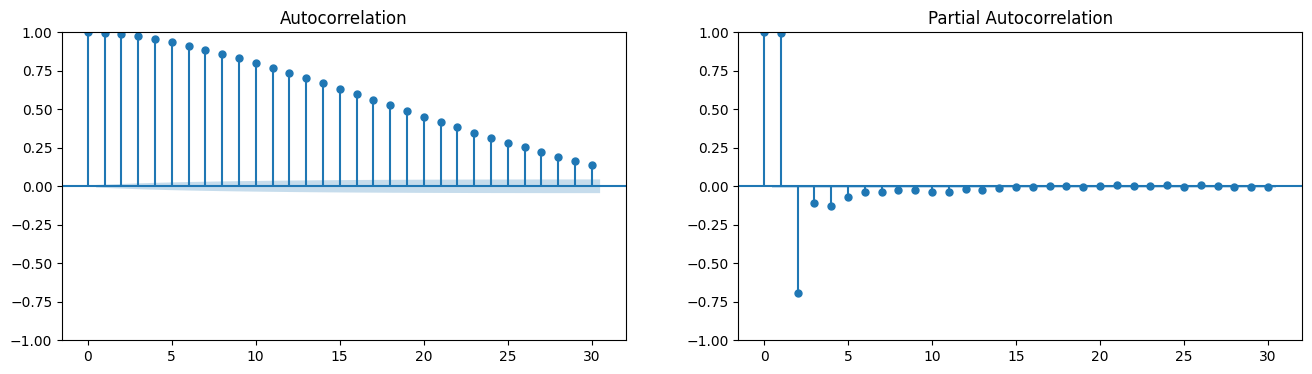

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts_zone1, lags=30, ax=axes[0])
plot_pacf(ts_zone1, lags=30, ax=axes[1])
plt.show()

In [14]:
import warnings
warnings.filterwarnings("ignore")
#The values ​​are taken into account by the graphs
p, d, q = 1, 0, 0 
model = ARIMA(ts_zone1, order=(p, d, q))
model_train = model.fit()
print(model_train.summary())

                                 SARIMAX Results                                  
Dep. Variable:     PowerConsumption_Zone1   No. Observations:                52416
Model:                     ARIMA(1, 0, 0)   Log Likelihood             -412362.544
Date:                    Sat, 09 May 2026   AIC                         824731.089
Time:                            11:55:50   BIC                         824757.689
Sample:                        01-01-2017   HQIC                        824739.403
                             - 12-30-2017                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.234e+04    740.805     43.662      0.000    3.09e+04    3.38e+04
ar.L1          0.9961      0.000   2292.051      0.000       0.995       0.997
sigma2      3.988e+0

In [12]:
import warnings
warnings.filterwarnings("ignore")
# Testing new configurations to clean the residuals
orders_to_test = [(2, 0, 0), (1, 0, 1), (1, 1, 1)]

for order in orders_to_test:
    try:
        test_model = ARIMA(ts_zone1, order=order)
        test_result = test_model.fit()
        
        print(f"--- ARIMA Model{order} ---")
        print(f"AIC: {test_result.aic}")
        
        residuals = test_result.resid
        
        # Extract the Ljung-Box p-value for the first lag
        p_value_lb = acorr_ljungbox(residuals, np.arange(1, 2)).iloc[0, 1]
        
        print(f"Ljung-Box P-value (Lag 1): {p_value_lb}\n")
        
    except:
        continue

--- ARIMA Model(2, 0, 0) ---
AIC: 790043.5963142238
Ljung-Box P-value (Lag 1): 7.697712973823923e-70

--- ARIMA Model(1, 0, 1) ---
AIC: 802464.3298118382
Ljung-Box P-value (Lag 1): 0.0

--- ARIMA Model(1, 1, 1) ---
AIC: 790161.2217977976
Ljung-Box P-value (Lag 1): 0.00457005584048479



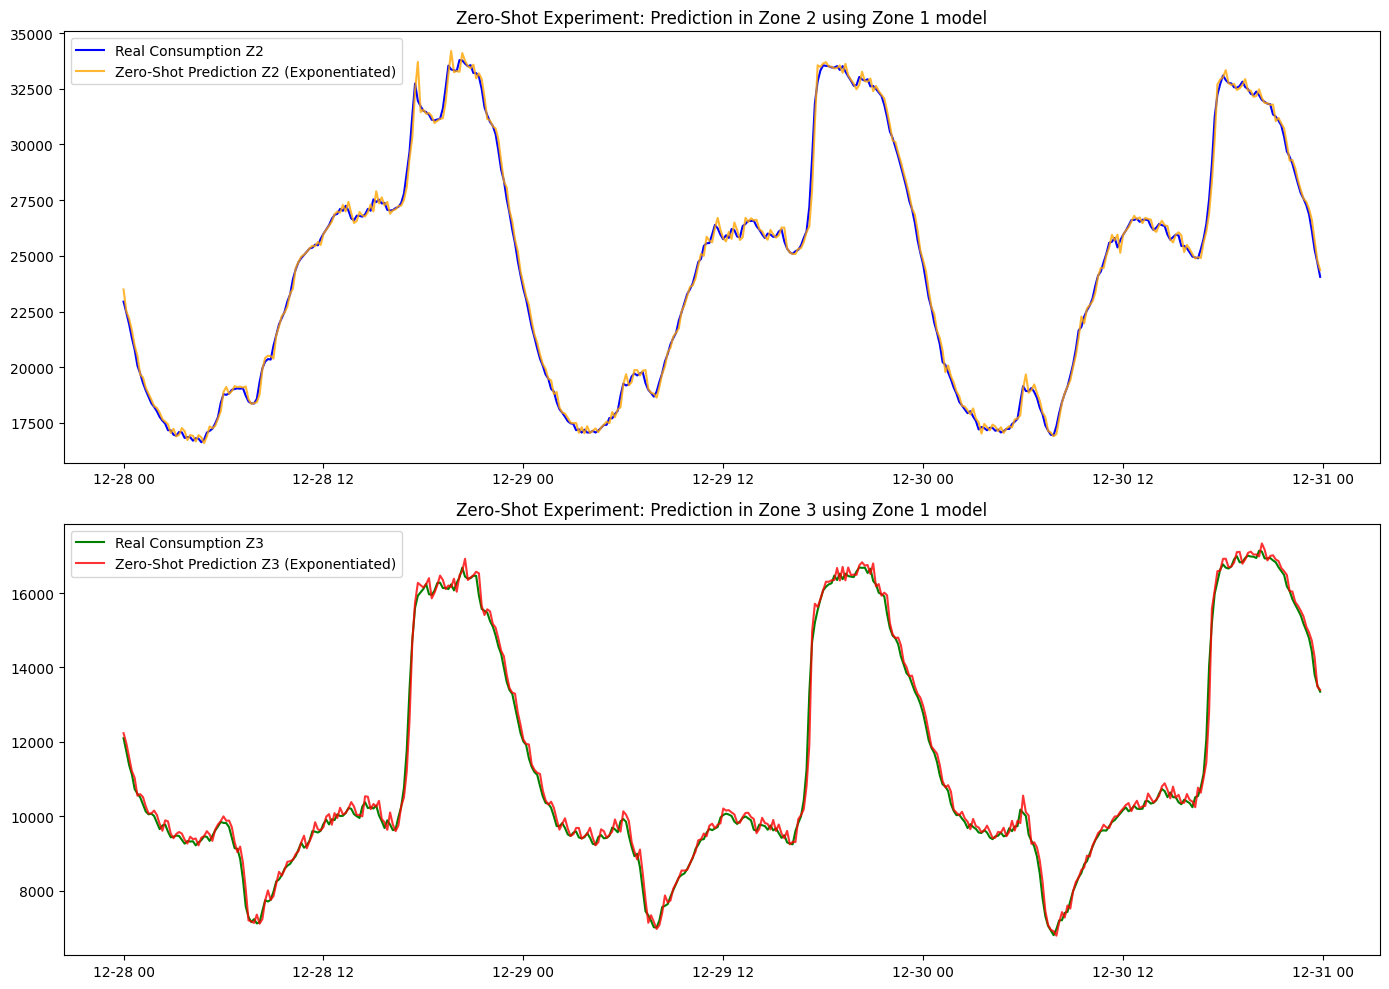

In [15]:
import warnings
warnings.filterwarnings("ignore")

# 1. Logarithmic transformation of the original series
ts_zone1_log = np.log(df['PowerConsumption_Zone1'])
ts_zone2_log = np.log(df['PowerConsumption_Zone2'])
ts_zone3_log = np.log(df['PowerConsumption_Zone3'])

# 2. Train the final model on Zone 1 using logarithmic data
final_model_z1 = ARIMA(ts_zone1_log, order=(2, 0, 0))
trained_model_z1 = final_model_z1.fit()

# 3. Zero-shot experiment: We filter using logarithmic data from Z2 and Z3
zs_model_z2 = ARIMA(ts_zone2_log, order=(2, 0, 0)).filter(trained_model_z1.params)
predictions_z2_log = zs_model_z2.predict()

zs_model_z3 = ARIMA(ts_zone3_log, order=(2, 0, 0)).filter(trained_model_z1.params)
predictions_z3_log = zs_model_z3.predict()

# 4. Reverse the logarithm (exponential) to bring data back to real kilowatts
predictions_z2_real = np.exp(predictions_z2_log)
predictions_z3_real = np.exp(predictions_z3_log)

# Extract original real consumption for comparison in the plot
ts_zone2_real = df['PowerConsumption_Zone2']
ts_zone3_real = df['PowerConsumption_Zone3']

# 5. Plot a segment (e.g. last 3 days = 432 records of 10 minutes)
window = -432 

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Zone 2 plot
axes[0].plot(ts_zone2_real.index[window:], ts_zone2_real.iloc[window:], label='Real Consumption Z2', color='blue')
axes[0].plot(predictions_z2_real.index[window:], predictions_z2_real.iloc[window:], label='Zero-Shot Prediction Z2 (Exponentiated)', color='orange', alpha=0.8)
axes[0].set_title('Zero-Shot Experiment: Prediction in Zone 2 using Zone 1 model')
axes[0].legend()

# Zone 3 plot
axes[1].plot(ts_zone3_real.index[window:], ts_zone3_real.iloc[window:], label='Real Consumption Z3', color='green')
axes[1].plot(predictions_z3_real.index[window:], predictions_z3_real.iloc[window:], label='Zero-Shot Prediction Z3 (Exponentiated)', color='red', alpha=0.8)
axes[1].set_title('Zero-Shot Experiment: Prediction in Zone 3 using Zone 1 model')
axes[1].legend()

plt.tight_layout()
plt.show()